In [151]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

- Analysera datan
- Hur många datapunkter och attribut finns?
- Hur många klasser av kvalitet finns det?
- Hur ser distributionen ut för de olika attributen?
- Finns det något attribut som inte borde användas?


In [152]:
df= pd.read_csv('../data collections/WineQT (1).csv')

print(df.shape, '\n') # 1143 datapunkter med 13 attribut
print(df.nunique(), '\n') # 6 olika klasser av kvalitet

print(df.describe())
print(df.info())

print('\n',df['quality'].value_counts())

(1143, 13) 

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64 

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000       

Datasetet består av 1143 datapunkter med 13 attribut. Datan har inga saknade värden eller strängvariabler som beöver kodas om.

Flera attribut ser ut att vara högerskeva, speciellt residual sugar, chlorides, free sulfur, total sulfur, sulfates och alcohol. Det ser ut att finnas extremvärden i datan för dessa columner vilket kan påverka modellen.

Fördelningen av target datan ser obalanserad ut med ett intervall mellan 3-8 där mean är ungefär 5.6 
Mer än 75% av raderna har Quality på 5 eller 6 vilket troligen kommer göra det svårare för modellen att identifiera rader där quality är lägre eller större än 5 och 6.

Den ända feature som tydligt inte borde avändas är ID då den inte bidrar med någon meningsfull information.

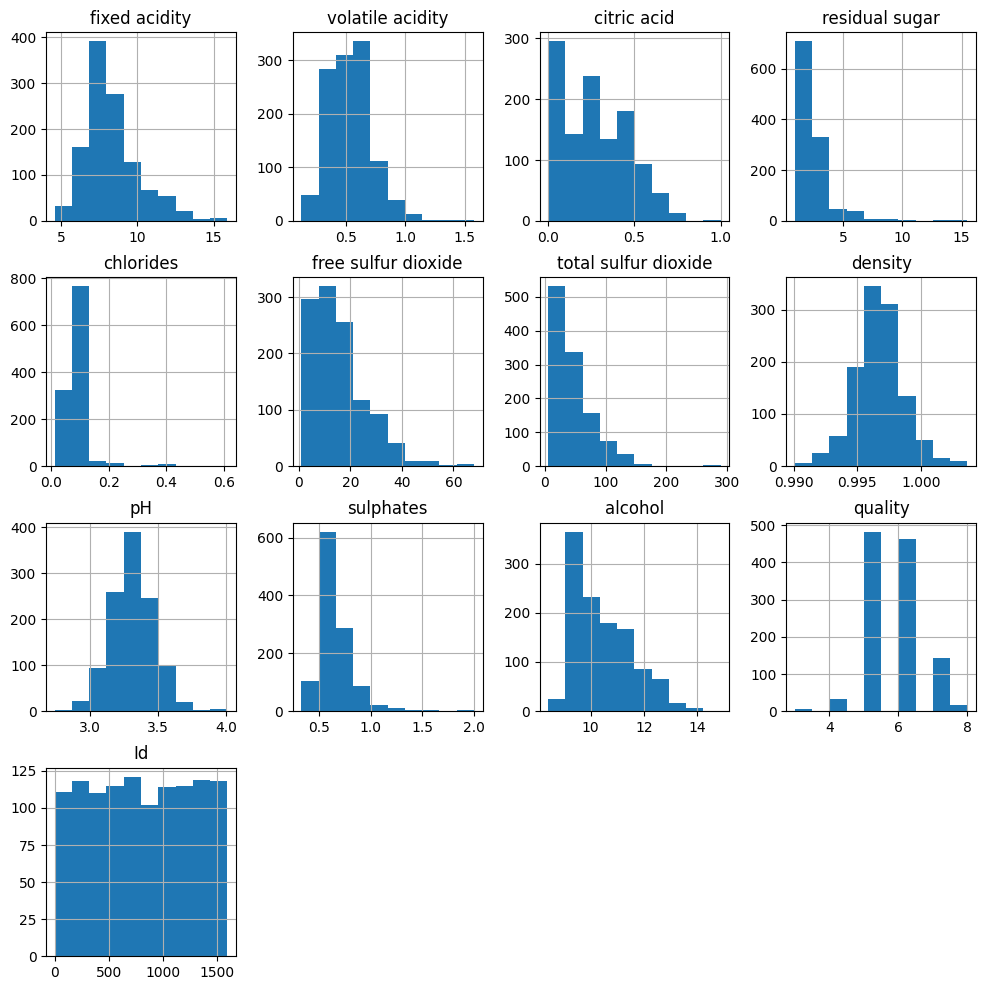

In [153]:
df.hist(figsize=(12,12))
plt.show()

In [154]:


X= df.drop(['quality', 'Id'], axis=1)
y= df.quality


X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, train_size= 0.8, random_state=0)

dt= DecisionTreeClassifier(random_state=0)


In [155]:
params= {
    'max_depth': [None, 4, 8, 12, 20],
    'min_samples_split':[ 2, 4, 6, 10], 
    'min_samples_leaf': [6, 10, 15, 20],
    'criterion': ['gini', 'entropy', 'log_loss']
}

grid_search= GridSearchCV(estimator=dt, param_grid=params, cv=5, verbose=2, scoring='accuracy')

grid_search.fit(X_train, y_train)

print('Bästa parameterna: ', grid_search.best_params_)
print('Bästa score: ', grid_search.best_score_)


best_model= grid_search.best_estimator_

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=6, min_samples_split=4; total time=   0.0s
[CV] END criterion=gini, ma

In [156]:
prediction= best_model.predict(X_test)

train_score=best_model.score(X_train, y_train)
print('Train score:', train_score)

#test score: 
test_score= best_model.score(X_test, y_test)
print('Test Score:', test_score)
print('Trädets djup:', best_model.get_depth())
print('Antal löv:', best_model.get_n_leaves())

features= pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print('\nBästa features:\n', features )

print(classification_report(y_test, prediction))

Train score: 0.6969365426695843
Test Score: 0.6026200873362445
Trädets djup: 9
Antal löv: 45

Bästa features:
 alcohol                 0.291185
sulphates               0.206663
total sulfur dioxide    0.130721
volatile acidity        0.128717
chlorides               0.075641
fixed acidity           0.052247
density                 0.038247
free sulfur dioxide     0.036066
citric acid             0.026664
pH                      0.007830
residual sugar          0.006019
dtype: float64
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.69      0.77      0.73       100
           6       0.57      0.52      0.55        92
           7       0.39      0.48      0.43        27
           8       0.00      0.00      0.00         2

    accuracy                           0.60       229
   macro avg       0.28      0.30      0.28       229
weighted avg       0.58

c:\Users\David Danell\Desktop\jupyter notebook\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\David Danell\Desktop\jupyter notebook\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\David Danell\Desktop\jupyter notebook\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

modellen får ~0.7 i trainscore och ~0.6 i testscore vilket visar ett den presterar betydligt bättre på träningsdatan. Skillnaden tyder på viss overfitting och det kan löna sig att sänka djupet samt höja min sample leaf och min sample split.

Djupet är 9 och antal löv är 45.

De attribut med best påverkan i ordning är: alcohol, sulphates, total sulfur dioxide och volatile acidity enligt modellens feature importance.



In [ ]:
from sklearn.ensemble import RandomForestClassifier



rf= RandomForestClassifier(random_state=0, n_jobs=2)

X_train_new, X_test_new, y_train_new, y_test_new= train_test_split(X, y, test_size=0.2, train_size= 0.8, random_state=0)



In [158]:


params={
    'n_estimators': [ 400],
    'max_depth': [None, 4, 8, 12],
    'min_samples_leaf': [4, 6, 10],
    'max_features':['sqrt', 'log2'],
    'criterion': ['gini', 'entropy', 'log_loss']
}

grid_search2= GridSearchCV(estimator=rf, param_grid=params, cv=5, verbose=2, scoring='accuracy', n_jobs=4)

grid_search2.fit(X_train_new, y_train_new)

model2=grid_search2.best_estimator_

print('Bästa parameterna: ', grid_search2.best_params_)
train_score2=model2.score(X_train_new, y_train_new)
print('Train score:', train_score2)

test_score2= model2.score(X_test_new, y_test_new)
print('Test Score:', test_score2)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Bästa parameterna:  {'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 400}
Train score: 0.8785557986870897
Test Score: 0.7074235807860262
